In [ ]:
# Adding in our imports prior to beginning the project
import shap
import xgboost
import lightgbm
import catboost
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from xgboost import XGBRegressor
from econml.dml import LinearDML
from joblib import dump

In [ ]:
df = pd.read_csv('/content/data.csv')
df.head(6)

,ticker,Name,environment_score,social_score,governance_score,total_score,Total ESG Risk score,Environment Risk Score,Governance Risk Score,Social Risk Score,...,Date,adj_close_lag_1,adj_close_lag_7,adj_close_lag_30,ma_7,ma_30,volatility_7,volatility_30,composite_esg_score,composite_esg_risk_score
0,DIS,The Walt Disney Company,510,316,321,1147,15.7,0.0,6.7,9.0,...,2019-02-14 00:00:00+00:00,108.017479,110.428772,106.811852,108.293337,108.769948,0.892777,1.251017,382.333333,5.233333
1,DIS,The Walt Disney Company,510,316,321,1147,15.7,0.0,6.7,9.0,...,2019-02-15 00:00:00+00:00,108.468369,109.203529,104.224129,108.458567,108.974481,1.157181,0.946782,382.333333,5.233333
2,DIS,The Walt Disney Company,510,316,321,1147,15.7,0.0,6.7,9.0,...,2019-02-19 00:00:00+00:00,110.360138,108.752617,107.439171,108.817039,109.101906,1.576243,0.989315,382.333333,5.233333
3,DIS,The Walt Disney Company,510,316,321,1147,15.7,0.0,6.7,9.0,...,2019-02-20 00:00:00+00:00,111.261925,109.301544,108.370354,109.120899,109.203846,1.863966,1.065930,382.333333,5.233333
4,DIS,The Walt Disney Company,510,316,321,1147,15.7,0.0,6.7,9.0,...,2019-02-21 00:00:00+00:00,111.428558,107.272537,109.213318,109.800034,109.297619,1.942662,1.183993,382.333333,5.233333
5,DIS,The Walt Disney Company,510,316,321,1147,15.7,0.0,6.7,9.0,...,2019-02-22 00:00:00+00:00,112.026482,107.037285,110.438568,110.647203,109.381915,1.826637,1.346851,382.333333,5.233333


In [ ]:
df.shape

(296334, 24)

In [ ]:
print(df.isnull().sum())

ticker                      0
Name                        0
environment_score           0
social_score                0
governance_score            0
total_score                 0
Total ESG Risk score        0
Environment Risk Score      0
Governance Risk Score       0
Social Risk Score           0
adj_close                   0
market_cap                  0
pe_ratio                    0
dividend_yield              0
Date                        0
adj_close_lag_1             0
adj_close_lag_7             0
adj_close_lag_30            0
ma_7                        0
ma_30                       0
volatility_7                0
volatility_30               0
composite_esg_score         0
composite_esg_risk_score    0
dtype: int64


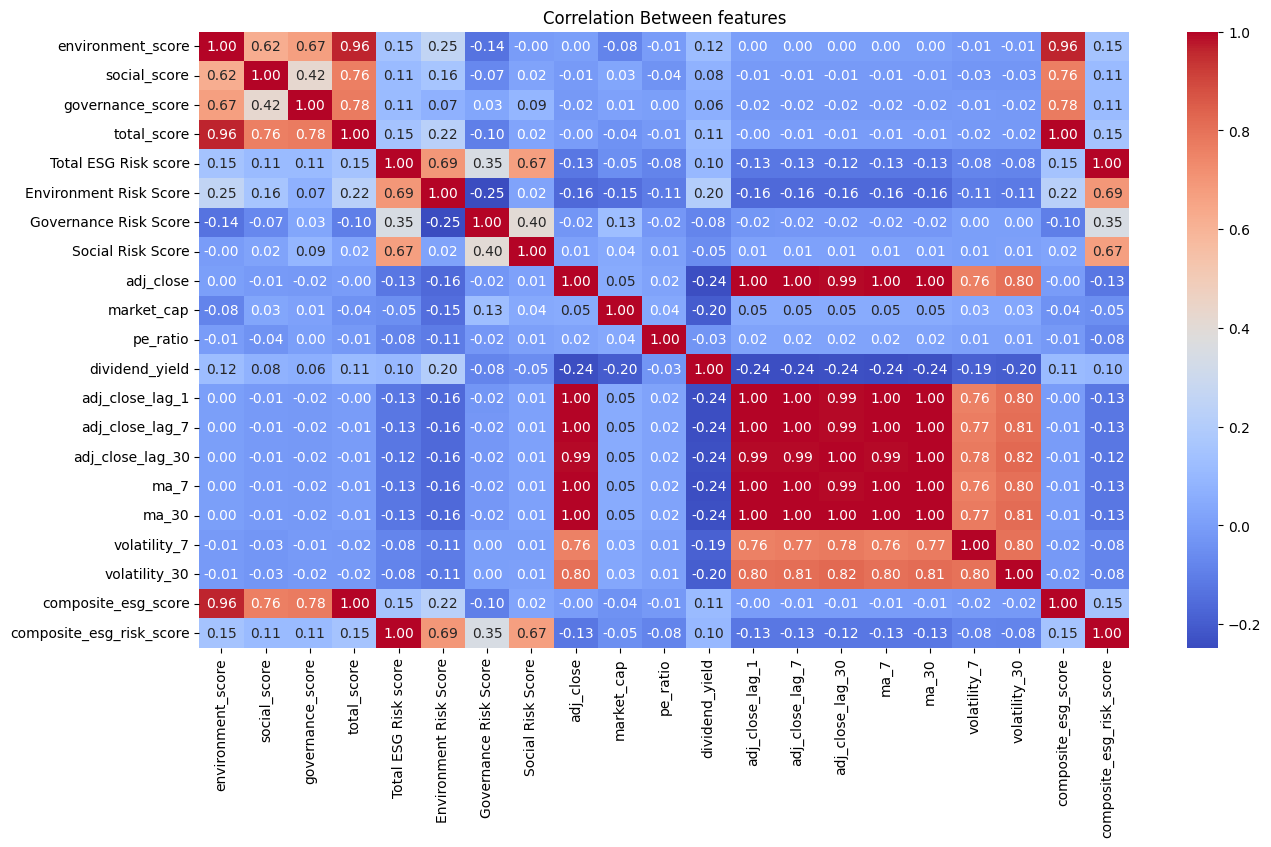


Các cặp biến có tương quan cao:
total_score           composite_esg_score         1.000000
Total ESG Risk score  composite_esg_risk_score    0.999961
adj_close             adj_close_lag_1             0.999632
adj_close_lag_1       ma_7                        0.999594
adj_close             ma_7                        0.999345
adj_close_lag_7       ma_7                        0.998999
                      ma_30                       0.998540
ma_7                  ma_30                       0.998207
adj_close_lag_1       adj_close_lag_7             0.997893
adj_close             adj_close_lag_7             0.997587
adj_close_lag_1       ma_30                       0.997378
adj_close             ma_30                       0.997123
adj_close_lag_30      ma_30                       0.996808
adj_close_lag_7       adj_close_lag_30            0.993023
adj_close_lag_30      ma_7                        0.992659
adj_close_lag_1       adj_close_lag_30            0.991874
adj_close             a

In [ ]:
# Select relevant columns for correlation
df_corr = df.drop(columns=['ticker', 'Name', 'Date'])
# Tính ma trận tương quan
correlation_matrix = df_corr.corr()
# Plot heatmap
plt.figure(figsize=(15, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between features")
plt.show()
# Tìm các cặp biến có tương quan cao (>|0.8|)
high_corr = (
    correlation_matrix
    .abs()
    .where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
    .stack()
    .loc[lambda x: x > 0.8]
    .sort_values(ascending=False)
)
print("\nCác cặp biến có tương quan cao:")
print(high_corr)


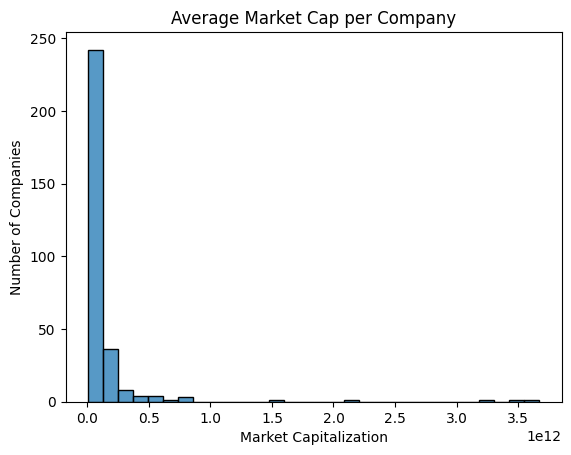

In [ ]:
df_avg = df.groupby("ticker")['market_cap'].mean()

sns.histplot(df_avg, bins=30)
plt.title("Average Market Cap per Company")
plt.xlabel("Market Capitalization")
plt.ylabel("Number of Companies")
plt.show()

In [ ]:
#Modeling
df['log_market_cap'] = np.log(df['market_cap'])
# Drop columns that are not features or targets
df['Date'] = pd.to_datetime(df['Date']) # Convert 'Date' column to datetime
df = df.sort_values(["ticker", "Date"]).reset_index(drop=True)
df = df.sort_values(["Date", "ticker"]).reset_index(drop=True)
target = df["adj_close"]
features = df.drop(columns=[
    "ticker","Name","Date",
    "adj_close",
    "adj_close_lag_7","adj_close_lag_30",
    "volatility_30","ma_30",
    "market_cap",
    "composite_esg_score","total_score","Total ESG Risk score","composite_esg_risk_score"
])

n = len(df)

cut1 = df["Date"].quantile(0.8)
cut2 = df["Date"].quantile(0.9)

train_mask = df["Date"] <= cut1
val_mask   = (df["Date"] > cut1) & (df["Date"] <= cut2)
test_mask  = df["Date"] > cut2

X_train, y_train = features[train_mask], target[train_mask]
X_val,   y_val   = features[val_mask],   target[val_mask]
X_test,  y_test  = features[test_mask],  target[test_mask]
# Scale the features (feature scaling): để tránh trường hợp giá trị của 1 cột to nhiều so với cột còn lại (vd:" cột A: 1000, cột B: 0.1")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# hàm đánh giá mô hình qua: MAE, MSE, R2 , Accuracy,F1 score (độ giải thích của mô hình)
def evaluate_model(model, X_val, y_val):
    predictions = model.predict(X_val)
    mae = mean_absolute_error(y_val, predictions)
    mse = mean_squared_error(y_val, predictions)
    r2 = r2_score(y_val, predictions)
    return mae, mse, r2

In [ ]:
# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_mae, lr_mse, lr_r2 = evaluate_model(lr_model, X_val_scaled, y_val)
print("Linear Regression: MAE =", lr_mae, "MSE =", lr_mse, "R² =", lr_r2)

Linear Regression: MAE = 2.095274107232016 MSE = 21.822323567446425 R² = 0.9990231837432918


In [ ]:
# Ridge Regression
ridge = Ridge()
ridge.fit(X_train_scaled, y_train)
ridge_mae, ridge_mse, ridge_r2 = evaluate_model(ridge, X_val_scaled, y_val)
print("Ridge Regression: MAE =", ridge_mae, "MSE =", ridge_mse, "R² =", ridge_r2,)

Ridge Regression: MAE = 2.095451136031179 MSE = 21.82298496302694 R² = 0.9990231541377389


In [ ]:
# Random Forest Regressor
#Tuning
# Using a smaller subset of the data for hyperparameter tuning
subset_size = 10000  # không dùng toàn bộ để tuning toàn bộ để tiết kiệm tài nguyên
X_train_subset = X_train_scaled[:subset_size]
y_train_subset = y_train.iloc[:subset_size]

# Random Forest hyperparameter tuning with reduced search space and subset of data
rf_params = {
    'n_estimators': [100, 200], #số cây
    'max_depth': [10, 20],  #độ sâu tối đa của mỗi cây
    'min_samples_split': [2, 5] #cMột node trong cây phải có ít nhất 2 (hoặc 5) quan sát thì mới được phép chia tiếp.
}

from sklearn.model_selection import TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=3) #Không trộn dữ liệu quá khứ – tương lai

rf_grid = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    rf_params,
    n_iter=10,
    cv=tscv,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    random_state=42
) #thử ngẫu 10 tổ hợp tham số, Đánh giá bằng MSE
rf_grid.fit(X_train_subset, y_train_subset)
best_rf = rf_grid.best_estimator_
rf_mae, rf_mse, rf_r2 = evaluate_model(best_rf, X_val_scaled, y_val)
print("Random Forest: MAE =", rf_mae, "MSE =", rf_mse, "R² =", rf_r2)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 8 is smaller than n_iter=10. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Random Forest: MAE = 6.4440204160718135 MSE = 683.6215142496137 R² = 0.9693995643272988


In [ ]:
# Gradient Boosting
#After tuning
# Gradient Boosting hyperparameter tuning with reduced search space and subset of data
gb_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5],
    'min_samples_split': [2, 5]
}

gb_grid = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=42),
    gb_params,
    n_iter=10,
    cv=tscv,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    random_state=42
)
gb_grid.fit(X_train_subset, y_train_subset)
best_gb = gb_grid.best_estimator_
gb_mae, gb_mse, gb_r2 = evaluate_model(best_gb, X_val_scaled, y_val)
print("Gradient Boosting: MAE =", gb_mae, "MSE =", gb_mse, "R² =", gb_r2)

Gradient Boosting: MAE = 6.224434997227672 MSE = 634.249501477912 R² = 0.9716095666010139


In [ ]:
#XGBRegressor
# 1. Define parameter space
xgb_params = {
    'n_estimators': [200, 300],
    'learning_rate': [0.01, 0.03],
    'max_depth': [3, 4],
    'subsample': [0.7, 0.8],
    'colsample_bytree': [0.7, 0.8],
    'min_child_weight': [5, 10],
    'gamma': [0, 0.1]
}

# 2. RandomizedSearchCV (giống format bạn dùng)
xgb_grid = RandomizedSearchCV(
    XGBRegressor(
        objective='reg:squarederror',
        random_state=42
    ),
    xgb_params,
    n_iter=10,          # số lần thử
    cv=tscv,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    random_state=42
)

# 3. Fit
xgb_grid.fit(X_train_subset, y_train_subset)
# 4. Best model
best_xgb = xgb_grid.best_estimator_
# 5. Evaluate (dùng hàm evaluate_model bạn đã có)
xgb_mae, xgb_mse, xgb_r2 = evaluate_model(best_xgb, X_val_scaled, y_val)
# 6. Print kết quả
print("XGBoost: MAE =", xgb_mae, "MSE =", xgb_mse, "R² =", xgb_r2)

XGBoost: MAE = 20.402334863684946 MSE = 11110.08622160738 R² = 0.502687566649161


In [ ]:
lr_mae_train, lr_mse_train, lr_r2_train = evaluate_model(lr_model, X_train_scaled, y_train)
ridge_mae_train, ridge_mse_train, ridge_r2_train = evaluate_model(ridge, X_train_scaled, y_train)
rf_mae_train, rf_mse_train, rf_r2_train = evaluate_model(best_rf, X_train_scaled, y_train)
gb_mae_train, gb_mse_train, gb_r2_train = evaluate_model(best_gb, X_train_scaled, y_train)
xgb_mae_train, xgb_mse_train, xgb_r2_train = evaluate_model(best_xgb, X_train_scaled, y_train)
results_train = pd.DataFrame({
    'Model': ['Random Forest', 'Gradient Boosting', 'Linear Regression', 'Ridge Regression', 'XGBoost'],
    'MAE': [rf_mae_train, gb_mae_train, lr_mae_train, ridge_mae_train, xgb_mae_train],
    'MSE': [rf_mse_train, gb_mse_train, lr_mse_train, ridge_mse_train, xgb_mse_train],
    'R²': [rf_r2_train, gb_r2_train, lr_r2_train, ridge_r2_train, xgb_r2_train]
})
print(f"Training Performance Results (In-sample Evaluation):\n{results_train}")

Training Performance Results (In-sample Evaluation):
               Model        MAE          MSE        R²
0      Random Forest   4.181760   573.631928  0.970989
1  Gradient Boosting   4.046764   540.745709  0.972652
2  Linear Regression   1.503012    13.384626  0.999323
3   Ridge Regression   1.503019    13.384838  0.999323
4            XGBoost  10.539852  4323.159699  0.781356


In [ ]:
# Compile the results into a DataFrame for comparison in validation
results_vali = pd.DataFrame({
    'Model': ['Random Forest', 'Gradient Boosting', 'Linear Regression', 'Ridge Regression', 'XGBoost'],
    'MAE': [rf_mae, gb_mae, lr_mae, ridge_mae, xgb_mae],
    'MSE': [rf_mse, gb_mse, lr_mse, ridge_mse, xgb_mse],
    'R²': [rf_r2, gb_r2, lr_r2, ridge_r2, xgb_r2]
})
print(f"Valid Performance Results:\n{results_vali}")

Valid Performance Results:
               Model        MAE           MSE        R²
0      Random Forest   6.444020    683.621514  0.969400
1  Gradient Boosting   6.224435    634.249501  0.971610
2  Linear Regression   2.095274     21.822324  0.999023
3   Ridge Regression   2.095451     21.822985  0.999023
4            XGBoost  20.402335  11110.086222  0.502688


In [ ]:
lr_mae_test, lr_mse_test, lr_r2_test = evaluate_model(lr_model, X_test_scaled, y_test)
ridge_mae_test, ridge_mse_test, ridge_r2_test = evaluate_model(ridge, X_test_scaled, y_test)
rf_mae_test, rf_mse_test, rf_r2_test = evaluate_model(best_rf, X_test_scaled, y_test)
gb_mae_test, gb_mse_test, gb_r2_test = evaluate_model(best_gb, X_test_scaled, y_test)
xgb_mae_test, xgb_mse_test, xgb_r2_test = evaluate_model(best_xgb, X_test_scaled, y_test)
results_vali = pd.DataFrame({
    'Model': ['Random Forest', 'Gradient Boosting', 'Linear Regression', 'Ridge Regression', 'XGBoost'],
    'MAE': [rf_mae_test, gb_mae_test, lr_mae_test, ridge_mae_test, xgb_mae_test],
    'MSE': [rf_mse_test, gb_mse_test, lr_mse_test, ridge_mse_test, xgb_mse_test],
    'R²': [rf_r2_test, gb_r2_test, lr_r2_test, ridge_r2_test, xgb_r2_test]
})
print(f"Test Performance Results:\n{results_vali}")

Test Performance Results:
               Model        MAE           MSE        R²
0      Random Forest   6.272357    583.350294  0.971830
1  Gradient Boosting   6.093583    528.926571  0.974458
2  Linear Regression   1.929984     15.459645  0.999253
3   Ridge Regression   1.930625     15.462345  0.999253
4            XGBoost  19.209928  10781.208497  0.479367


                   feature  mean_abs_shap
8          adj_close_lag_1      63.172357
9                     ma_7      11.927534
10            volatility_7       0.144936
7           dividend_yield       0.019561
11          log_market_cap       0.014132
5        Social Risk Score       0.010065
3   Environment Risk Score       0.004406
0        environment_score       0.002942
4    Governance Risk Score       0.002295
6                 pe_ratio       0.001375
2         governance_score       0.000921
1             social_score       0.000468


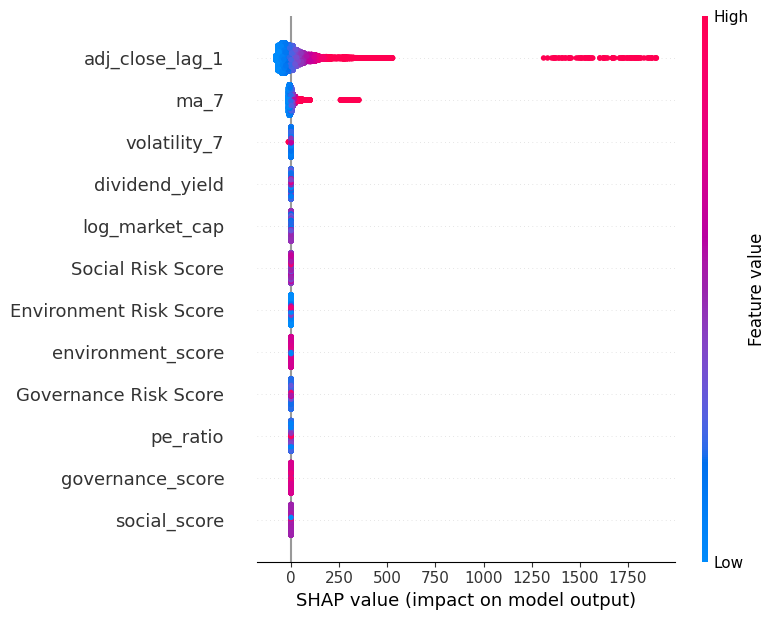

In [ ]:
# explainer cho Liner
explainer = shap.LinearExplainer(lr_model, X_train_scaled)

# shap values cho tập validation
shap_values = explainer.shap_values(X_val_scaled)
#bảng mean |SHAP|
mean_abs_shap = pd.DataFrame({
    "feature": X_val.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False)
print(mean_abs_shap)
shap.summary_plot(
    shap_values,
    pd.DataFrame(X_val_scaled, columns=X_val.columns)
)

In [ ]:
#return theo tháng ESG risk score
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['ticker', 'Date'])
df['year_month'] = df['Date'].dt.to_period('M')
df['year_month'] = df['Date'].dt.to_period('M')

monthly_price = (
    df.groupby(['ticker', 'year_month'])['adj_close']
      .last()
      .reset_index()
)
monthly_price['ret_1m'] = (
    monthly_price.groupby('ticker')['adj_close']
                 .pct_change()
)
firm_ret = (
    monthly_price
      .groupby('ticker')
      .agg(
          Y_mean_ret=('ret_1m', 'mean')
      )
      .reset_index()
)

firm_static = (
    df.groupby('ticker')
      .agg(
          market_cap_mean=('market_cap', 'mean'),
          volatility_mean=('volatility_30', 'mean'),
          pe_mean=('pe_ratio', 'mean'),
          div_mean=('dividend_yield', 'mean'),
          Environment_Risk=('Environment Risk Score', 'first'),
          Social_Risk=('Social Risk Score', 'first'),
          Governance_Risk=('Governance Risk Score', 'first')
      )
      .reset_index()
)

firm_df = firm_ret.merge(firm_static, on='ticker').dropna()
Y = firm_df['Y_mean_ret'].values
X = firm_df[['market_cap_mean', 'volatility_mean', 'pe_mean', 'div_mean']].values

esg_score_cols = {
    'Environment Risk Score': 'Environment_Risk',
    'Social Risk Score': 'Social_Risk',
    'Governance Risk Score': 'Governance_Risk'
}

results = []

for name, col in esg_score_cols.items():
    T = firm_df[[col]].values

    model = LinearDML(
        model_y=Ridge(alpha=1.0),
        model_t=Ridge(alpha=1.0),
        cv=3,
        random_state=42
    )

    model.fit(Y=Y, T=T, X=X)
    eff = model.effect(X)

    results.append([name, eff.mean(), abs(eff).mean()])

risk_causal_monthly_df = pd.DataFrame(
    results,
    columns=['feature', 'ATE_mean', 'mean_abs_effect']
)

risk_causal_monthly_df

/tmp/ipython-input-658120180.py:4: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['year_month'] = df['Date'].dt.to_period('M')
/tmp/ipython-input-658120180.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['year_month'] = df['Date'].dt.to_period('M')
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=3.99224e-26): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=3.99224e-26): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.39592e-26): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.p

,feature,ATE_mean,mean_abs_effect
0,Environment Risk Score,0.000384,0.000391
1,Social Risk Score,-0.000170,0.000183
2,Governance Risk Score,-0.000053,0.000156


,feature,ATE_mean,mean_abs_effect
0,Environment Risk Score,0.000384,0.000391
1,Social Risk Score,-0.000170,0.000183
2,Governance Risk Score,-0.000053,0.000156


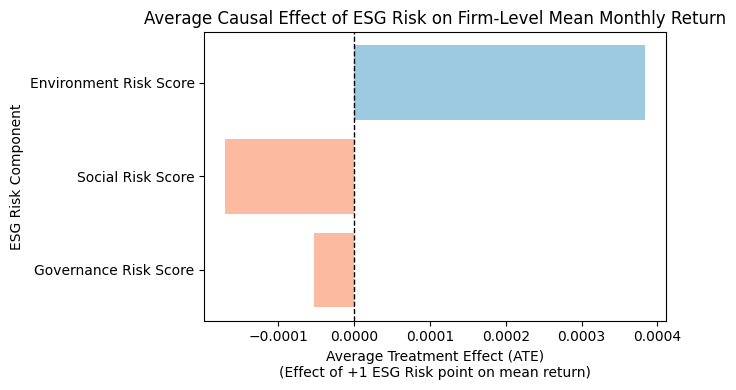

In [ ]:
display(risk_causal_monthly_df)
pos_color = '#9ecae1'   # light blue
neg_color = '#fcbba1'   # light red

colors = [pos_color if x > 0 else neg_color for x in risk_causal_monthly_df['ATE_mean']]

plt.figure(figsize=(7,4))
plt.barh(
    risk_causal_monthly_df['feature'],
    risk_causal_monthly_df['ATE_mean'],
    color=colors
)
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.gca().invert_yaxis()

plt.title("Average Causal Effect of ESG Risk on Firm-Level Mean Monthly Return")
plt.xlabel("Average Treatment Effect (ATE)\n(Effect of +1 ESG Risk point on mean return)")
plt.ylabel("ESG Risk Component")

plt.tight_layout()
plt.show()

In [ ]:
#return theo tháng ESG score
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['ticker', 'Date'])
df['year_month'] = df['Date'].dt.to_period('M')
df['year_month'] = df['Date'].dt.to_period('M')

monthly_price = (
    df.groupby(['ticker', 'year_month'])['adj_close']
      .last()
      .reset_index()
)
monthly_price['ret_1m'] = (
    monthly_price.groupby('ticker')['adj_close']
                 .pct_change()
)
firm_ret = (
    monthly_price
      .groupby('ticker')
      .agg(
          Y_mean_ret=('ret_1m', 'mean')
      )
      .reset_index()
)

firm_static = (
    df.groupby('ticker')
      .agg(
          market_cap_mean=('market_cap', 'mean'),
          volatility_mean=('volatility_30', 'mean'),
          pe_mean=('pe_ratio', 'mean'),
          div_mean=('dividend_yield', 'mean'),
          environment_score=('environment_score', 'first'),
          social_score=('social_score', 'first'),
          governance_score=('governance_score', 'first')
      )
      .reset_index()
)

firm_df = firm_ret.merge(firm_static, on='ticker').dropna()
Y = firm_df['Y_mean_ret'].values
X = firm_df[['market_cap_mean', 'volatility_mean', 'pe_mean', 'div_mean']].values

esg_score_cols = {
    'Environment Score': 'environment_score',
    'Social Score': 'social_score',
    'Governance Score': 'governance_score'
}

results = []

for name, col in esg_score_cols.items():
    T = firm_df[[col]].values

    model = LinearDML(
        model_y=Ridge(alpha=1.0),
        model_t=Ridge(alpha=1.0),
        cv=3,
        random_state=42
    )

    model.fit(Y=Y, T=T, X=X)
    eff = model.effect(X)

    results.append([name, eff.mean(), abs(eff).mean()])

score_causal_monthly_df = pd.DataFrame(
    results,
    columns=['feature', 'ATE_mean', 'mean_abs_effect']
)

score_causal_monthly_df


/tmp/ipython-input-3896933192.py:4: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['year_month'] = df['Date'].dt.to_period('M')
/tmp/ipython-input-3896933192.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['year_month'] = df['Date'].dt.to_period('M')
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=3.99224e-26): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=3.99224e-26): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.39592e-26): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util

,feature,ATE_mean,mean_abs_effect
0,Environment Score,0.000008,0.000008
1,Social Score,0.000003,0.000006
2,Governance Score,0.000011,0.000014


,feature,ATE_mean,mean_abs_effect
0,Environment Score,0.000008,0.000008
1,Social Score,0.000003,0.000006
2,Governance Score,0.000011,0.000014


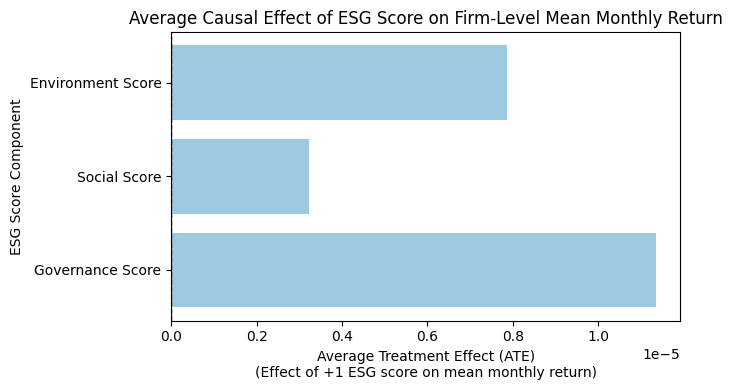

In [ ]:
display(score_causal_monthly_df)

colors = [pos_color if x > 0 else neg_color for x in score_causal_monthly_df['ATE_mean']]

plt.figure(figsize=(7,4))
plt.barh(
    score_causal_monthly_df['feature'],
    score_causal_monthly_df['ATE_mean'],
    color=colors
)
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.gca().invert_yaxis()

plt.title("Average Causal Effect of ESG Score on Firm-Level Mean Monthly Return")
plt.xlabel("Average Treatment Effect (ATE)\n(Effect of +1 ESG score on mean monthly return)")
plt.ylabel("ESG Score Component")

plt.tight_layout()
plt.show()

In [ ]:
#return theo năm risk score
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['ticker', 'Date'])
df['year'] = df['Date'].dt.year

yearly_price = (
    df.groupby(['ticker', 'year'])['adj_close']
      .last()
      .reset_index()
)

yearly_price['ret_1y'] = (
    yearly_price.groupby('ticker')['adj_close']
    .pct_change()
)
firm_ret = (
    yearly_price
    .groupby('ticker')
    .agg(
        Y_mean_ret=('ret_1y', 'mean')
    )
    .reset_index()
)
firm_static = (
    df.groupby('ticker')
    .agg(
        market_cap_mean=('market_cap', 'mean'),
          volatility_mean=('volatility_30', 'mean'),
          pe_mean=('pe_ratio', 'mean'),
          div_mean=('dividend_yield', 'mean'),
        Environment_Risk=('Environment Risk Score', 'first'),
        Social_Risk=('Social Risk Score', 'first'),
        Governance_Risk=('Governance Risk Score', 'first')
    )
    .reset_index()
)
firm_df = firm_ret.merge(firm_static, on='ticker').dropna()

Y = firm_df['Y_mean_ret'].values
X = firm_df[['market_cap_mean', 'volatility_mean', 'pe_mean', 'div_mean']].values
esg_score_cols = {
    'Environment Risk Score': 'Environment_Risk',
    'Social Risk Score': 'Social_Risk',
    'Governance Risk Score': 'Governance_Risk'
}

results = []

for name, col in esg_score_cols.items():
    T = firm_df[[col]].values

    model = LinearDML(
        model_y=Ridge(alpha=1.0),
        model_t=Ridge(alpha=1.0),
        cv=3,
        random_state=42
    )

    model.fit(Y=Y, T=T, X=X)
    eff = model.effect(X)

    results.append([name, eff.mean(), abs(eff).mean()])
    risk_causal_yearly_df = pd.DataFrame(
    results,
    columns=['feature', 'ATE_mean', 'mean_abs_effect']
)

risk_causal_yearly_df

/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=3.99224e-26): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=3.99224e-26): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.39592e-26): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.39592e-26): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=4.90603e-26): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/pytho

,feature,ATE_mean,mean_abs_effect
0,Environment Risk Score,0.005569,0.005593
1,Social Risk Score,-0.003478,0.003563
2,Governance Risk Score,-0.000699,0.001061


,feature,ATE_mean,mean_abs_effect
0,Environment Risk Score,0.005569,0.005593
1,Social Risk Score,-0.003478,0.003563
2,Governance Risk Score,-0.000699,0.001061


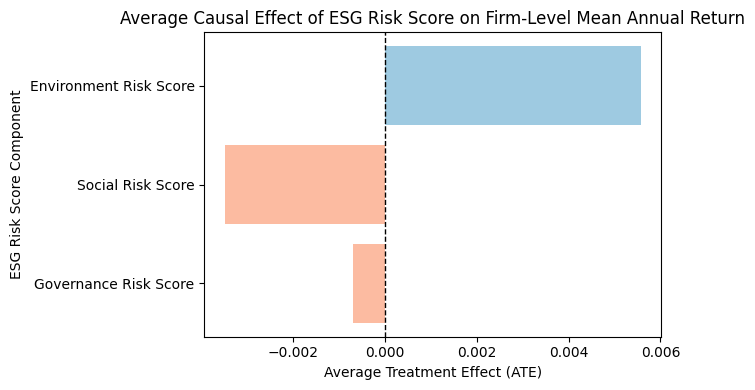

In [ ]:
display(risk_causal_yearly_df)
colors = [pos_color if x > 0 else neg_color for x in risk_causal_yearly_df['ATE_mean']]

plt.figure(figsize=(7,4))
plt.barh(
    risk_causal_yearly_df['feature'],
    risk_causal_yearly_df['ATE_mean'],
    color=colors
)
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.gca().invert_yaxis()

plt.title("Average Causal Effect of ESG Risk Score on Firm-Level Mean Annual Return")
plt.xlabel("Average Treatment Effect (ATE)")
plt.ylabel("ESG Risk Score Component")

plt.tight_layout()
plt.show()

In [ ]:
#return theo năm score
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['ticker', 'Date'])
df['year'] = df['Date'].dt.year

yearly_price = (
    df.groupby(['ticker', 'year'])['adj_close']
      .last()
      .reset_index()
)

yearly_price['ret_1y'] = (
    yearly_price.groupby('ticker')['adj_close']
    .pct_change()
)
firm_ret = (
    yearly_price
    .groupby('ticker')
    .agg(
        Y_mean_ret=('ret_1y', 'mean')
    )
    .reset_index()
)
firm_static = (
    df.groupby('ticker')
    .agg(
        market_cap_mean=('market_cap', 'mean'),
          volatility_mean=('volatility_30', 'mean'),
          pe_mean=('pe_ratio', 'mean'),
          div_mean=('dividend_yield', 'mean'),
        environment_score=('environment_score', 'first'),
        social_score=('social_score', 'first'),
        governance_score=('governance_score', 'first')
    )
    .reset_index()
)
firm_df = firm_ret.merge(firm_static, on='ticker').dropna()

Y = firm_df['Y_mean_ret'].values
X = firm_df[['market_cap_mean', 'volatility_mean', 'pe_mean', 'div_mean']].values
esg_score_cols = {
    'Environment Score': 'environment_score',
    'Social Score': 'social_score',
    'Governance Score': 'governance_score'
}

results = []

for name, col in esg_score_cols.items():
    T = firm_df[[col]].values

    model = LinearDML(
        model_y=Ridge(alpha=1.0),
        model_t=Ridge(alpha=1.0),
        cv=3,
        random_state=42
    )

    model.fit(Y=Y, T=T, X=X)
    eff = model.effect(X)

    results.append([name, eff.mean(), abs(eff).mean()])
    score_causal_yearly_df = pd.DataFrame(
    results,
    columns=['feature', 'ATE_mean', 'mean_abs_effect']
)

score_causal_yearly_df

/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=3.99224e-26): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=3.99224e-26): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.39592e-26): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.39592e-26): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=4.90603e-26): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/pytho

,feature,ATE_mean,mean_abs_effect
0,Environment Score,0.000133,0.000146
1,Social Score,0.000095,0.000132
2,Governance Score,0.000029,0.000078


,feature,ATE_mean,mean_abs_effect
0,Environment Score,0.000133,0.000146
1,Social Score,0.000095,0.000132
2,Governance Score,0.000029,0.000078


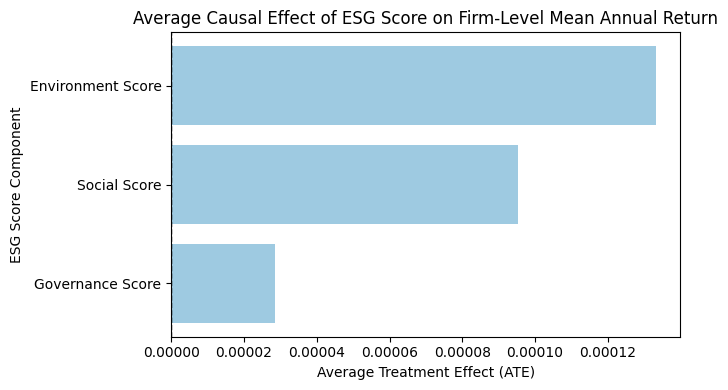

In [ ]:
display(score_causal_yearly_df)
colors = [pos_color if x > 0 else neg_color for x in score_causal_yearly_df['ATE_mean']]

plt.figure(figsize=(7,4))
plt.barh(
    score_causal_yearly_df['feature'],
    score_causal_yearly_df['ATE_mean'],
    color=colors
)
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.gca().invert_yaxis()

plt.title("Average Causal Effect of ESG Score on Firm-Level Mean Annual Return")
plt.xlabel("Average Treatment Effect (ATE)")
plt.ylabel("ESG Score Component")

plt.tight_layout()
plt.show()

In [ ]:
#lưu file
dump({"model": lr_model, "scaler": scaler}, "linear.joblib")
dump({"model": ridge, "scaler": scaler}, "ridge.joblib")
dump({"model": best_rf, "scaler": scaler}, "rf.joblib")
dump({"model": best_gb, "scaler": scaler}, "gb.joblib")
dump({"model": best_xgb, "scaler": scaler}, "xgb.joblib")
import zipfile

model_files = [
    "linear.joblib",
    "ridge.joblib",
    "rf.joblib",
    "gb.joblib",
    "xgb.joblib"
]

with zipfile.ZipFile("models.zip", "w", zipfile.ZIP_DEFLATED) as zipf:
    for f in model_files:
        zipf.write(f)

print("Zipped models into models.zip")
from google.colab import files

files.download("models.zip")

Zipped models into models.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>